In [18]:
# !pip install torch torchvision timm albumentations scikit-learn matplotlib

## 1. Importing the Required Libraries

In [51]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image

## 2. Define data path

In [55]:
# data_dir = "./OCT diabetic images/"
data_dir = "./oct_100_per_class/"
batch_size = 16
image_size = 224

## Helper Methods

### Get Random Image function



In [56]:
def get_random_image(data_dir):
    classes = os.listdir(data_dir)
    class_name = random.choice(classes)

    class_path = os.path.join(data_dir, class_name)
    image_name = random.choice(os.listdir(class_path))

    return os.path.join(class_path, image_name)

### Original vs Preprocessed Images

In [71]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

def denormalize(img_tensor):
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array(imagenet_mean)
    std = np.array(imagenet_std)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

def show_comparison(image_path, transform):
    img = Image.open(image_path).convert("RGB")
    processed = transform(img)

    processed_img = denormalize(processed)

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))

    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(processed_img)
    ax[1].set_title("Preprocessed")
    ax[1].axis("off")

    plt.show()

### Pixel Intensity Histogram

In [72]:
import cv2
import numpy as np

def plot_histogram(image_path, transform):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    processed = transform(Image.fromarray(img))
    processed = processed.permute(1, 2, 0).numpy()

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(img.ravel(), bins=50)
    plt.title("Original Histogram")

    plt.subplot(1,2,2)
    plt.hist(processed.ravel(), bins=50)
    plt.title("Processed Histogram")

    plt.show()

### Channel-wise Visualization (RGB Channels)

In [73]:
def show_channels(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    r, g, b = cv2.split(img)

    fig, ax = plt.subplots(1, 3, figsize=(12,4))

    ax[0].imshow(r, cmap='Reds')
    ax[0].set_title("Red Channel")

    ax[1].imshow(g, cmap='Greens')
    ax[1].set_title("Green Channel")

    ax[2].imshow(b, cmap='Blues')
    ax[2].set_title("Blue Channel")

    for a in ax:
        a.axis("off")

    plt.show()

### Augmentation Visualization

In [74]:
def show_augmentations(image_path, transform, n=5):
    img = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(12,3))

    for i in range(n):
        aug = transform(img)
        plt.subplot(1, n, i+1)
        plt.imshow(aug.permute(1,2,0))
        plt.axis("off")

    plt.suptitle("Augmented Samples")
    plt.show()

### CLAHE Effect Visualization (IMPORTANT 🔥)

In [83]:
def show_clahe_effect(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge((l_clahe,a,b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

    fig, ax = plt.subplots(1,2, figsize=(8,4))

    ax[0].imshow(img)
    ax[0].set_title("Original")

    ax[1].imshow(img_clahe)
    ax[1].set_title("CLAHE Enhanced")

    for a in ax:
        a.axis("off")

    plt.show()

## 2.1 Data Preprocessing + Augmentation

### Implement Basic Transformation Pipeline

In [84]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform_A = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_transform_A = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

In [85]:
train_dataset = datasets.ImageFolder(
    root=data_dir + "/train",
    transform=train_transform_A
)

val_dataset = datasets.ImageFolder(
    root=data_dir + "/val",
    transform=val_transform_A
)

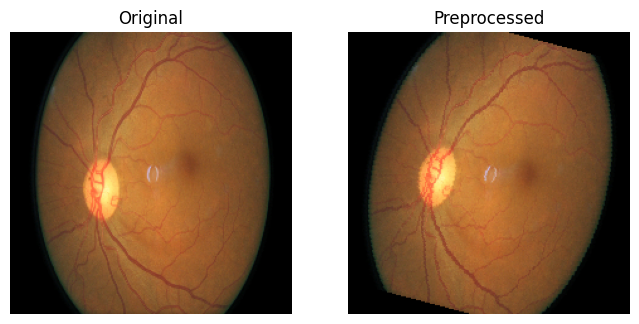

In [98]:
img_path = get_random_image("./oct_100_per_class/train")
show_comparison(img_path, train_transform_A)

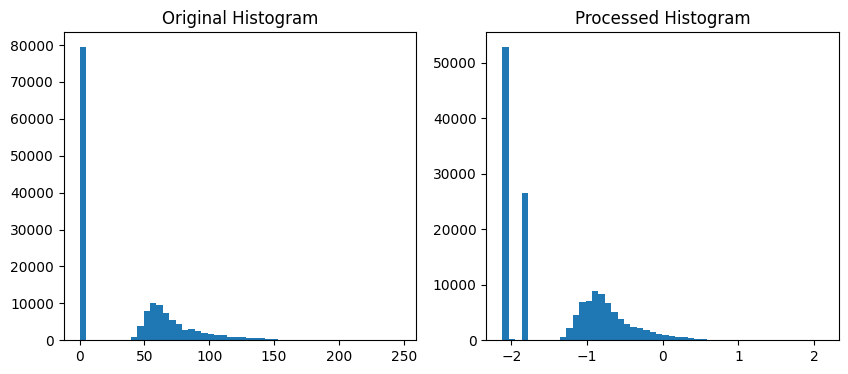

In [87]:
plot_histogram(img_path, train_transform_A)

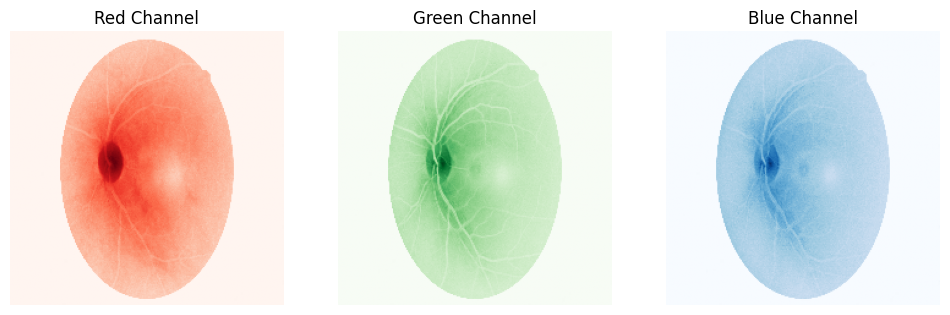

In [88]:
show_channels(img_path)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.11191].


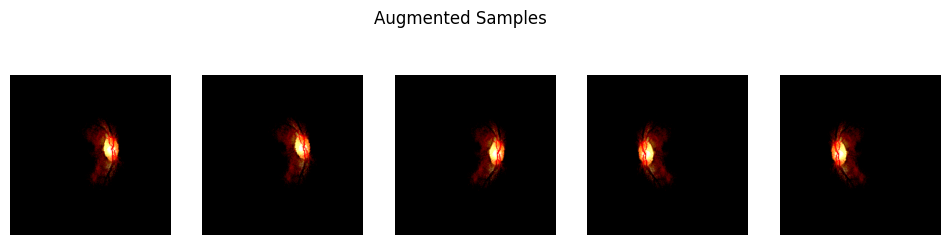

In [89]:
show_augmentations(img_path, train_transform_A)

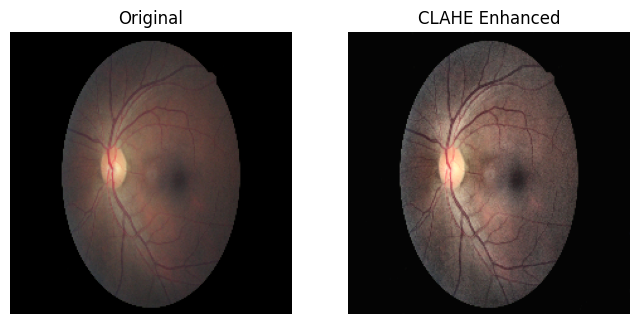

In [90]:
show_clahe_effect(img_path)

### Pipeline C — Advanced (Research Level 🚀)

In [27]:
train_transform_C = transforms.Compose([
    transforms.Resize((224, 224)),
    CLAHETransform(),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_transform_C = transforms.Compose([
    transforms.Resize((224, 224)),
    CLAHETransform(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

In [39]:
transform_vis = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

In [9]:
train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

val_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

5. Load Dataset

In [19]:
try:
    train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transforms)
    val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transforms)
    test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transforms)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    class_names = train_dataset.classes
    num_classes = len(class_names)
    
except Exception as error:
    print(f"{error}")

6. Model Loader Function

In [20]:
def get_model(model_name, num_classes):
    if model_name == "resnet":
        model = models.resnet50(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "densenet":
        model = models.densenet121(pretrained=True)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    elif model_name == "efficientnet":
        model = models.efficientnet_b0(pretrained=True)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == "vgg":
        model = models.vgg16(pretrained=True)
        model.classifier[6] = nn.Linear(4096, num_classes)

    else:
        raise ValueError("Invalid model")

    return model

7. Training Function

In [21]:
def train_model(model, train_loader, val_loader, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    return model, train_losses, val_losses

8. Evaluation Function

In [22]:
def evaluate_model(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(all_labels, all_preds))

9. Train Multiple Models

In [23]:
models_to_train = ["resnet", "densenet", "efficientnet", "vgg"]

trained_models = {}

for name in models_to_train:
    print(f"\nTraining {name.upper()}...\n")

    model = get_model(name, num_classes)
    model, train_loss, val_loss = train_model(model, train_loader, val_loader, epochs=10)

    trained_models[name] = model

    evaluate_model(model, test_loader)


Training RESNET...



C:\Users\nilot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\nilot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\nilot/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:28<00:00, 3.64MB/s]


Epoch 1/10, Train Loss: 1.3104, Val Loss: 1.2028


KeyboardInterrupt: 

10. Plot Loss Graph

In [ ]:
def plot_loss(train_loss, val_loss):
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.show()

11. Save Best Model

In [14]:
torch.save(model.state_dict(), "best_model.pth")

NameError: name 'model' is not defined